
# Tokenization & Text Preprocessing

*A lecture note on how raw text becomes the discrete units every NLP model
is actually built on top of.*

---

## 1. Intro: text isn't already a list of "words" to a computer

A sentence like `"I won't eat Dr. Smith's leftovers."` looks obviously
split into words to you. To a computer, it's just a string of characters —
`I`, space, `w`, `o`, `n`, `'`, `t`, space, ... — with no built-in notion of
"word" at all. **Tokenization** is the first, and easy-to-underestimate,
step of essentially every NLP system: deciding how to chop a string into
the discrete units (**tokens**) that everything downstream — a bag-of-words
model, a language model, a transformer — actually operates on.

Get tokenization wrong and everything downstream inherits the mistake: a
model trained on tokens that split `"won't"` into `won` and `t` (if you
naively split on apostrophes) will never learn that `n't` means "not" the
same way whether it appears in `won't`, `can't`, or `isn't`.

**By the end of this tutorial you'll be able to:**

- Explain why naive whitespace splitting fails, concretely, on real text.
- Implement and compare **stemming** vs. **lemmatization**, and state
  precisely what each one is (and isn't) doing to a word.
- Derive the **Byte-Pair Encoding (BPE)** algorithm — the subword
  tokenization scheme behind GPT, RoBERTa, and most modern LLMs — from
  scratch, and run it for real on a real corpus.
- Explain why subword tokenization exists at all: it's the fix for the
  **out-of-vocabulary (OOV) problem** that plagues whole-word tokenizers.



## 2. The idea, intuitively

Let's see whitespace splitting fail immediately, on a real sentence.


In [1]:

sentence = "I won't eat Dr. Smith's leftovers, even if they're free!"

naive_tokens = sentence.split(" ")
print("Naive whitespace split:")
print(naive_tokens)


Naive whitespace split:
['I', "won't", 'eat', 'Dr.', "Smith's", 'leftovers,', 'even', 'if', "they're", 'free!']



Look closely: `"won't"` stays glued together (should probably be two
meaning-units: `wo` + `n't`, or at least separated from punctuation),
`"Dr."` keeps its period (is `Dr` a different token than `Dr.`? probably
shouldn't be), and `"free!"` glues the exclamation mark onto `free`. A
model that's never seen the token `"free!"` before (only `"free"` and
`"free."` and `"free,"`) has to relearn "free" from scratch for every
punctuation variant — a huge, silent waste of what the model could be
learning.

**Rule-based tokenizers** (like NLTK's) use regular-expression heuristics
built up over decades to handle exactly these cases: split off punctuation,
keep certain abbreviations glued, split contractions in linguistically
sensible places.


In [2]:

import nltk
nltk.data.path.append(nltk.data.path[0])  # ensure default data path is used
from nltk.tokenize import word_tokenize

better_tokens = word_tokenize(sentence)
print("NLTK's rule-based tokenizer:")
print(better_tokens)


NLTK's rule-based tokenizer:
['I', 'wo', "n't", 'eat', 'Dr.', 'Smith', "'s", 'leftovers', ',', 'even', 'if', 'they', "'re", 'free', '!']



Much better: punctuation is split off as its own token, and `won't` is
correctly split into `wo` + `n't` (NLTK's Treebank-style convention — the
`n't` piece is treated as a standalone negation morpheme). This is still
just the *first* decision though — once you have tokens, you often want to
reduce them further so that `run`, `runs`, `running`, and `ran` are
recognized as "the same underlying idea." That's **stemming** and
**lemmatization**, which we'll formalize next.



## 3. Going deeper: the formal definitions

### 3.1 Stemming vs. lemmatization

Both **stemming** and **lemmatization** map an inflected word form to a
single canonical representative, but they do it in fundamentally different
ways:

- **Stemming** is a crude, rule-based, *morphological chopping* procedure
  that strips known suffixes without any understanding of the word's actual
  meaning or part of speech. The classic algorithm is the **Porter Stemmer**
  (Porter, 1980), which applies an ordered sequence of suffix-stripping
  rules (e.g. `SSES -> SS`, `IES -> I`, `ATIONAL -> ATE`) in multiple
  passes. Its output, the **stem**, is not guaranteed to be a real word —
  e.g. `"studies"` -> `"studi"`.
- **Lemmatization** looks a real word (the **lemma**) up using a
  morphological dictionary (e.g. WordNet) and the word's part of speech, so
  `"studies"` (verb) correctly maps to `"study"`, and `"better"` (adjective)
  correctly maps to `"good"` — a mapping no suffix-stripping rule could ever
  produce, since there's no shared substring between `better` and `good`.

The formal distinction: stemming is a **syntactic, context-free string
transformation**; lemmatization is a **semantic, dictionary + POS-aware
lookup**. Stemming is faster and requires no external knowledge base;
lemmatization is slower but linguistically correct.

### 3.2 Byte-Pair Encoding (BPE): subword tokenization

Whole-word tokenizers (whitespace or rule-based) share a structural flaw:
**the out-of-vocabulary (OOV) problem**. Any word not seen during training
— a typo, a rare technical term, a brand-new slang word — has no
representation. You're forced to either drop it, or map it to a generic
`<UNK>` token, discarding all of its information.

**Byte-Pair Encoding** (Sennrich, Haddow & Birch, 2016 — adapting a 1994
data-compression algorithm to NLP) solves this by tokenizing at the
**subword** level: instead of a fixed vocabulary of whole words, build a
vocabulary of frequently-occurring character sequences, learned directly
from the training corpus.

**The BPE training algorithm**, precisely:

1. Initialize the vocabulary as the set of individual characters in the
   corpus. Represent every word as a sequence of these characters (plus an
   end-of-word marker, so `"low"` becomes `l o w </w>`).
2. Count the frequency of every **adjacent symbol pair** across the entire
   (word-frequency-weighted) corpus.
3. Merge the single most frequent pair into a new symbol, and add it to the
   vocabulary.
4. Repeat steps 2–3 for a fixed number of merges (a hyperparameter — this
   directly controls the final vocabulary size).

The result: common whole words (`"the"`, `"and"`) get merged all the way
into single tokens (since their component letter-pairs are always the most
frequent), while rare words stay split into smaller, still-meaningful
subword pieces (e.g. an unseen word `"tokenization"` might come out as
`token` + `ization` if both pieces were common enough during training)
— **and crucially, any string can always be tokenized, even one containing
characters never seen before, because you can always fall back to
individual characters.** This is why BPE (and its close relatives,
WordPiece used in BERT and SentencePiece) eliminates the OOV problem
entirely, at the cost of sometimes splitting a word into multiple tokens.


In [3]:

from collections import Counter, defaultdict

def get_pair_counts(word_freqs):
    pairs = Counter()
    for word, freq in word_freqs.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_pair(pair, word_freqs):
    bigram = " ".join(pair)
    replacement = "".join(pair)
    new_word_freqs = {}
    for word, freq in word_freqs.items():
        new_word = word.replace(bigram, replacement)
        new_word_freqs[new_word] = freq
    return new_word_freqs

def train_bpe(word_freqs, num_merges):
    word_freqs = {" ".join(list(w)) + " </w>": f for w, f in word_freqs.items()}
    merges = []
    for _ in range(num_merges):
        pairs = get_pair_counts(word_freqs)
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        merges.append((best_pair, pairs[best_pair]))
        word_freqs = merge_pair(best_pair, word_freqs)
    return word_freqs, merges

toy_corpus = Counter({"low": 5, "lower": 2, "newest": 6, "widest": 3, "low": 5})
final_words, merges = train_bpe(toy_corpus, num_merges=8)
print("Toy corpus word frequencies:", dict(toy_corpus))
print("\nMerges learned, in order (pair -> merge count):")
for (pair, count) in merges:
    print(f"  {pair}  (merged {count}x)")
print("\nFinal segmented forms:")
for w, f in final_words.items():
    print(f"  {w!r}  (freq {f})")


Toy corpus word frequencies: {'low': 5, 'lower': 2, 'newest': 6, 'widest': 3}

Merges learned, in order (pair -> merge count):
  ('e', 's')  (merged 9x)
  ('es', 't')  (merged 9x)
  ('est', '</w>')  (merged 9x)
  ('l', 'o')  (merged 7x)
  ('lo', 'w')  (merged 7x)
  ('n', 'e')  (merged 6x)
  ('ne', 'w')  (merged 6x)
  ('new', 'est</w>')  (merged 6x)

Final segmented forms:
  'low </w>'  (freq 5)
  'low e r </w>'  (freq 2)
  'newest</w>'  (freq 6)
  'w i d est</w>'  (freq 3)



Notice `low` and `lower` share the merge `l o -> lo` and `lo w -> low`
early on (since `low`-as-a-prefix is common to both words), while `newest`
and `widest` share the `e s t -> est` suffix merge. This is BPE's key
property: **frequent morphological pieces (prefixes, suffixes, whole common
words) get merged into single tokens, purely from frequency statistics —
no linguistic rules were hand-coded**, unlike the Porter stemmer's
hand-written suffix rules from §3.1.



## 4. Visuals: BPE vocabulary growth and real token-length behavior

We'll now move to a real corpus — Jane Austen's *Emma* (1815), bundled as
public-domain text in NLTK's Gutenberg corpus — and watch the BPE
vocabulary grow with each merge, plus look at the real distribution of
token lengths that rule-based tokenization produces.


In [4]:

import matplotlib.pyplot as plt
from nltk.corpus import gutenberg

raw_text = gutenberg.raw("austen-emma.txt")
print(f"Loaded Austen's Emma: {len(raw_text):,} characters")
print(raw_text[:300])


Loaded Austen's Emma: 887,071 characters
[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was t


191,851 tokens total, 6,932 distinct alphabetic word types


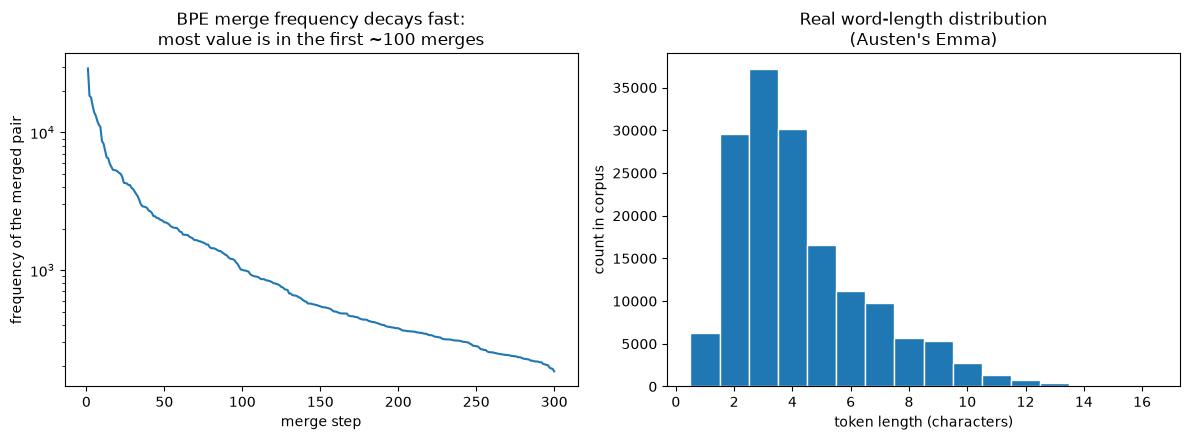

In [5]:

words = word_tokenize(raw_text.lower())
word_freqs_real = Counter(w for w in words if w.isalpha())
print(f"{len(words):,} tokens total, {len(word_freqs_real):,} distinct alphabetic word types")

# Train BPE on the real corpus, tracking vocabulary size after each merge.
_, real_merges = train_bpe(word_freqs_real, num_merges=300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

vocab_sizes = list(range(1, len(real_merges) + 1))
merge_freqs = [c for (_, c) in real_merges]
axes[0].plot(vocab_sizes, merge_freqs)
axes[0].set_xlabel("merge step"); axes[0].set_ylabel("frequency of the merged pair")
axes[0].set_title("BPE merge frequency decays fast:\nmost value is in the first ~100 merges")
axes[0].set_yscale("log")

token_lengths = [len(w) for w in word_freqs_real.elements()]
axes[1].hist(token_lengths, bins=range(1, 18), align="left", color="tab:blue", edgecolor="white")
axes[1].set_xlabel("token length (characters)"); axes[1].set_ylabel("count in corpus")
axes[1].set_title("Real word-length distribution\n(Austen's Emma)")

plt.tight_layout()
plt.savefig("bpe_and_lengths.png", dpi=130)
plt.show()



## 5. Implementation: stemming, lemmatization, and OOV handling on real text

### 5.1 Stemming vs. lemmatization, side by side, on real inflected words


In [6]:

from nltk.stem import PorterStemmer, WordNetLemmatizer
import pandas as pd

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

test_words = ["studies", "studying", "better", "running", "ran", "leaves",
              "geese", "wolves", "was", "meeting", "universal", "argued"]
pos_hint = ["v", "v", "a", "v", "v", "n", "n", "n", "v", "n", "a", "v"]

rows = []
for w, pos in zip(test_words, pos_hint):
    rows.append({"word": w, "porter stem": stemmer.stem(w),
                 "wordnet lemma (POS-aware)": lemmatizer.lemmatize(w, pos=pos)})
pd.DataFrame(rows)


,word,porter stem,wordnet lemma (POS-aware)
0,studies,studi,study
1,studying,studi,study
2,better,better,good
3,running,run,run
4,ran,ran,run
5,leaves,leav,leaf
6,geese,gees,goose
7,wolves,wolv,wolf
8,was,wa,be
9,meeting,meet,meeting



Look at `"better"` -> lemma `"good"`: no suffix-stripping rule could ever
produce that, since the strings share no common substring — the
lemmatizer used real morphological knowledge (WordNet's irregular
adjective mapping), not string surgery. Meanwhile `"studies"` -> stem
`"studi"` is not a real English word at all; the Porter stemmer doesn't
care, since its only job is consistency (mapping all inflected forms of a
root to the *same* string), not correctness.

### 5.2 Applying the trained BPE tokenizer to unseen, made-up words

The entire point of subword tokenization is that it **never fails on new
input** — let's prove that concretely with words that provably never
appeared in Austen's 1815 novel.


In [7]:

def apply_bpe(word, merges_in_order):
    symbols = list(word) + ["</w>"]
    for (pair, _) in merges_in_order:
        i = 0
        new_symbols = []
        while i < len(symbols):
            if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                new_symbols.append(symbols[i] + symbols[i + 1])
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1
        symbols = new_symbols
    return symbols

# Real BPE merges learned above (from Austen's Emma), applied to words that
# certainly never appeared in an 1815 novel.
unseen_words = ["tokenization", "smartphone", "coronavirus", "blockchain", "wifi"]
for w in unseen_words:
    pieces = apply_bpe(w, real_merges)
    print(f"{w!r:20s} -> {pieces}")


'tokenization'       -> ['to', 'k', 'en', 'i', 'z', 'a', 'tion</w>']
'smartphone'         -> ['s', 'm', 'ar', 't', 'p', 'h', 'on', 'e</w>']
'coronavirus'        -> ['c', 'or', 'on', 'a', 'vi', 'ru', 's</w>']
'blockchain'         -> ['b', 'lo', 'c', 'k', 'c', 'ha', 'in</w>']
'wifi'               -> ['wi', 'f', 'i</w>']



Every single modern word gets segmented into *something* — usually a mix
of recognizable English fragments and individual leftover characters —
rather than being discarded as `<UNK>`. This is exactly why every modern
large language model (GPT's `tiktoken`, BERT's WordPiece, LLaMA's
SentencePiece) uses a subword scheme instead of a fixed whole-word
vocabulary: **no input string can ever be untokenizable.**



## 6. Use cases

- **Every downstream NLP model in this domain** (bag-of-words, n-gram
  language models, word embeddings, RNNs, transformers) starts from a
  tokenizer's output — tokenization quality silently caps everything built
  on top of it.
- **Search engines** rely on stemming/lemmatization so a search for
  `"running shoes"` also matches documents containing `"run"` or `"runs"`.
- **Modern LLM tokenizers** (`tiktoken` for GPT models, SentencePiece for
  LLaMA/T5, WordPiece for BERT) are all BPE-family subword tokenizers
  trained the same way shown in §3.2/§4, just at a much larger scale
  (tens of thousands of merges on web-scale corpora instead of 300 merges
  on one novel).
- **Machine translation and multilingual models** rely heavily on subword
  tokenization specifically because it degrades gracefully across
  languages with very different vocabulary/morphology sizes, instead of
  needing a separate whole-word vocabulary per language.

## 7. Limitations & debates

- **Stemming routinely over-stems and under-stems.** Over-stemming:
  `"university"` and `"universe"` can collapse to a similar stem despite
  being semantically unrelated. Under-stemming: related words sometimes
  fail to merge (e.g. `"data"` / `"datum"`). This is a known, hard-to-fully
  fix limitation of any purely rule-based approach.
- **BPE's merges are determined entirely by training-corpus frequency, not
  linguistic correctness** — a token boundary can land in a linguistically
  nonsensical place if that's simply what was frequent (e.g. splitting a
  root across a merge boundary in an unexpected way for rare words).
- **Tokenizer bias across languages is a live, actively-studied fairness
  issue**: because BPE vocabularies are usually trained predominantly on
  English/web text, non-English (especially non-Latin-script, e.g.
  Amharic, Burmese) text often needs *far more tokens* to represent the
  same amount of information — which directly means non-English users pay
  more (in a metered API) and get less usable context window for the same
  amount of real text. This has been measured and published as a concrete
  disparity for major LLM tokenizers.
- **Whitespace-dependent tokenizers fail outright on languages without
  whitespace-delimited words** (Chinese, Japanese, Thai), which need
  dedicated word-segmentation models — a fundamentally different, harder
  problem than English tokenization, out of scope here but worth knowing
  by name (e.g. Jieba for Chinese).
- **The "right" vocabulary size for BPE is a real, debated hyperparameter**:
  too small and you fragment common words into many pieces (hurting model
  efficiency and context-length budget); too large and you approach the
  OOV problem of whole-word tokenization again, with less benefit from
  subword sharing.

## 8. References

- Porter, M.F. (1980). *An Algorithm for Suffix Stripping.* Program 14(3).
- Sennrich, R., Haddow, B., Birch, A. (2016). *Neural Machine Translation
  of Rare Words with Subword Units.* ACL 2016. (BPE for NLP)
- Devlin, J., Chang, M.W., Lee, K., Toutanova, K. (2019). *BERT:
  Pre-training of Deep Bidirectional Transformers for Language
  Understanding.* NAACL 2019. (WordPiece tokenization)
- Kudo, T. & Richardson, J. (2018). *SentencePiece: A simple and language
  independent subword tokenizer and detokenizer for Neural Text
  Processing.* EMNLP 2018.
- Manning, C.D., Raghavan, P., Schütze, H. (2008). *Introduction to
  Information Retrieval*, Chapter 2 (tokenization, stemming). Cambridge
  University Press.
- Ahia, O. et al. (2023). *Do All Languages Cost the Same? Tokenization in
  the Era of Commercial Language Models.* EMNLP 2023. (tokenizer
  cross-lingual disparity)
- NLTK Project. `nltk.tokenize`, `nltk.stem` documentation.
- Austen, J. (1815). *Emma* — public-domain text via NLTK's Gutenberg
  corpus.
